In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# PCA transformed mean no need for one hot encoding categorical text data. PCA take highly correlated features and compress into mathematical component based on variance and pattern. Original dataset contains sensitive information such as name, creditcard and username

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#Running ML Algorithm XGBoost, Gradientboosting and Random Forest Classifier

In [ ]:
X = data.drop('Class', axis=1)
y = data['Class']

# Drop class since it is what I want to predict


*   Class of 0 indicate no fraud
*   Class of 1 indicate fraud





In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

In [ ]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30)
]

#Viewing confusion matrix

RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.50      0.62        98

    accuracy                           1.00     56962
   macro avg       0.90      0.75      0.81     56962
weighted avg       1.00      1.00      1.00     56962



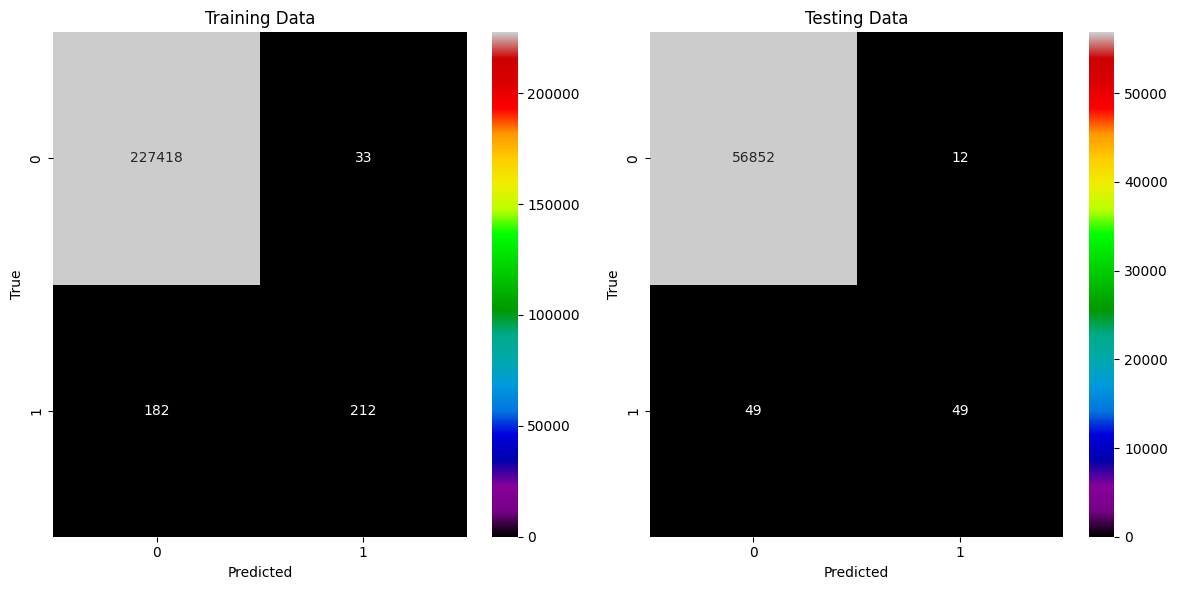

RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.64      0.76        98

    accuracy                           1.00     56962
   macro avg       0.96      0.82      0.88     56962
weighted avg       1.00      1.00      1.00     56962



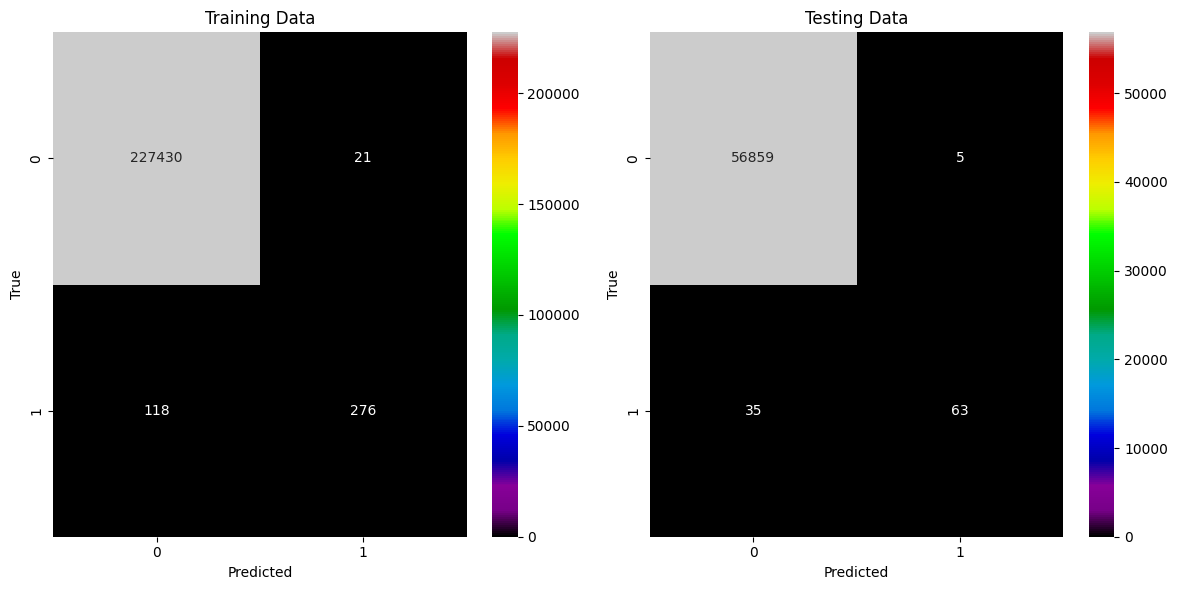

RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.71      0.83        98

    accuracy                           1.00     56962
   macro avg       0.99      0.86      0.91     56962
weighted avg       1.00      1.00      1.00     56962



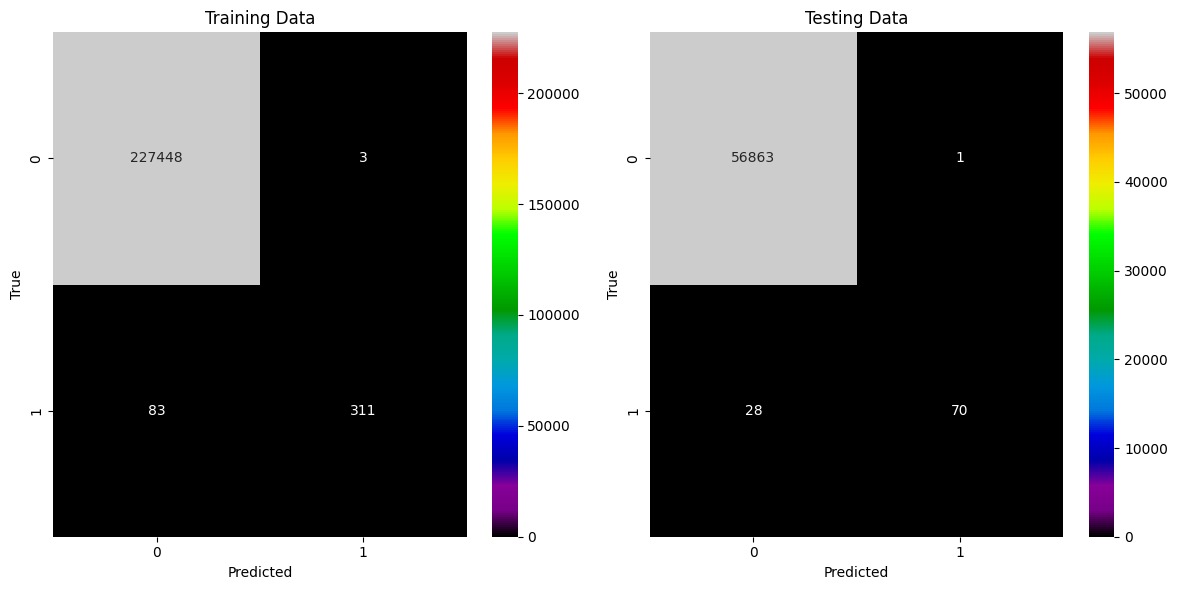

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.73      0.73        98

    accuracy                           1.00     56962
   macro avg       0.86      0.87      0.86     56962
weighted avg       1.00      1.00      1.00     56962



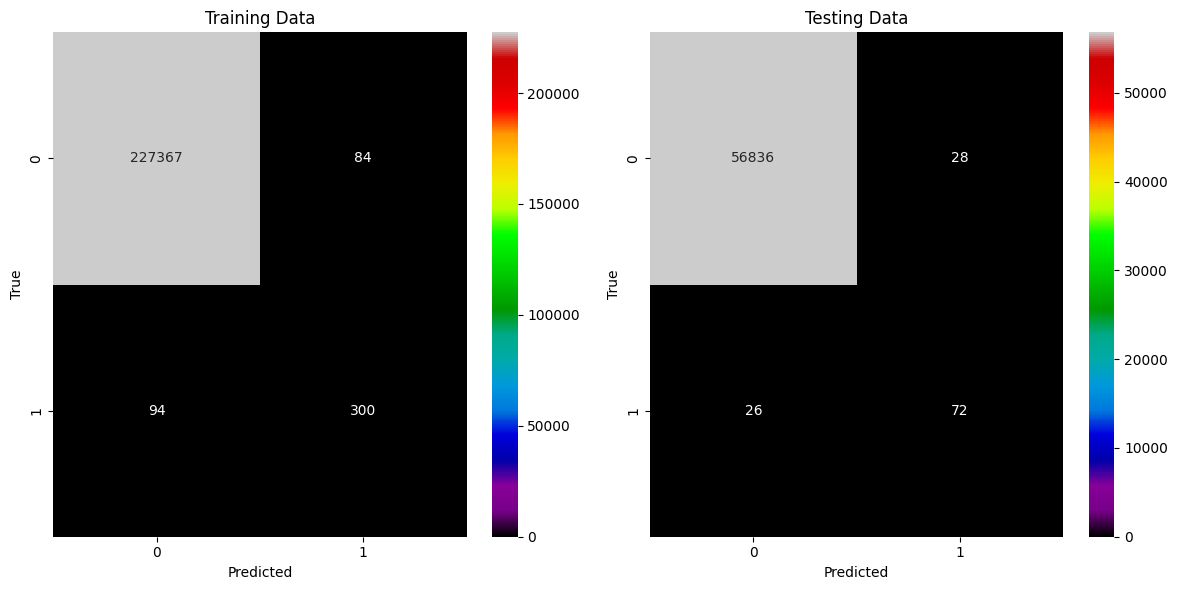

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.62      0.23      0.34        98

    accuracy                           1.00     56962
   macro avg       0.81      0.62      0.67     56962
weighted avg       1.00      1.00      1.00     56962



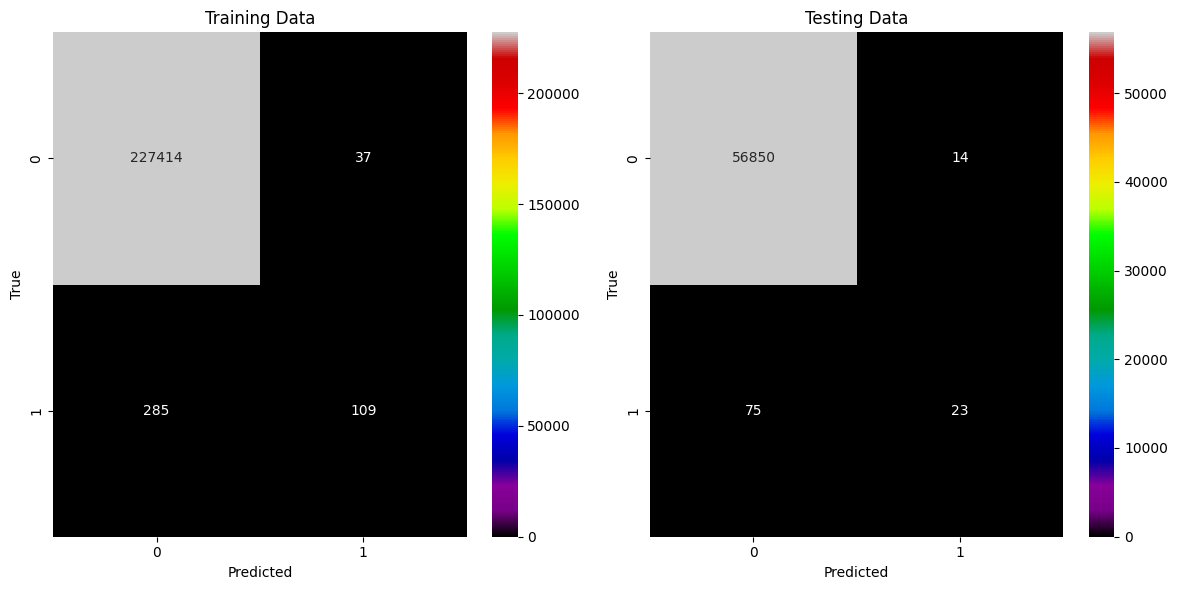

GradientBoostingClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.62      0.23      0.34        98

    accuracy                           1.00     56962
   macro avg       0.81      0.62      0.67     56962
weighted avg       1.00      1.00      1.00     56962



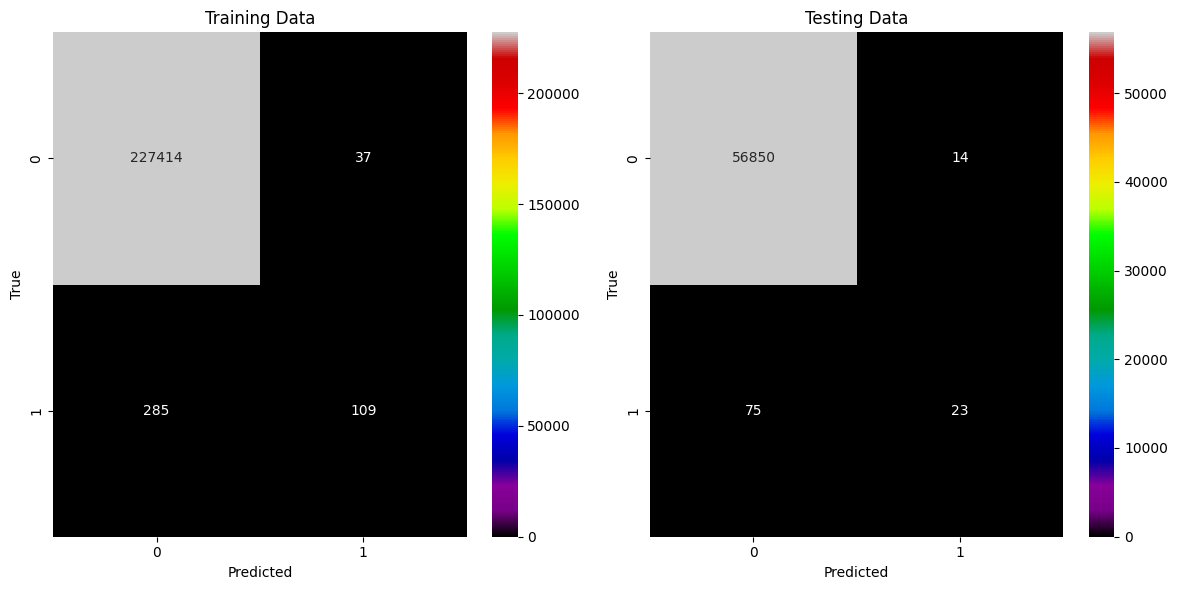

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:49:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=3, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      

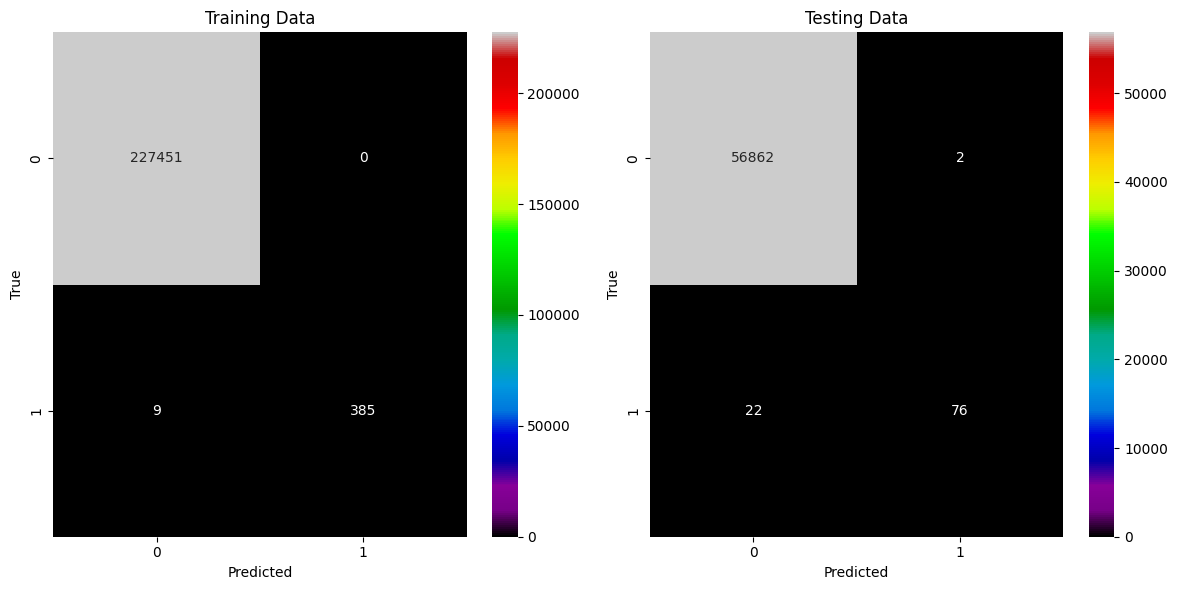

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:49:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=10, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99     

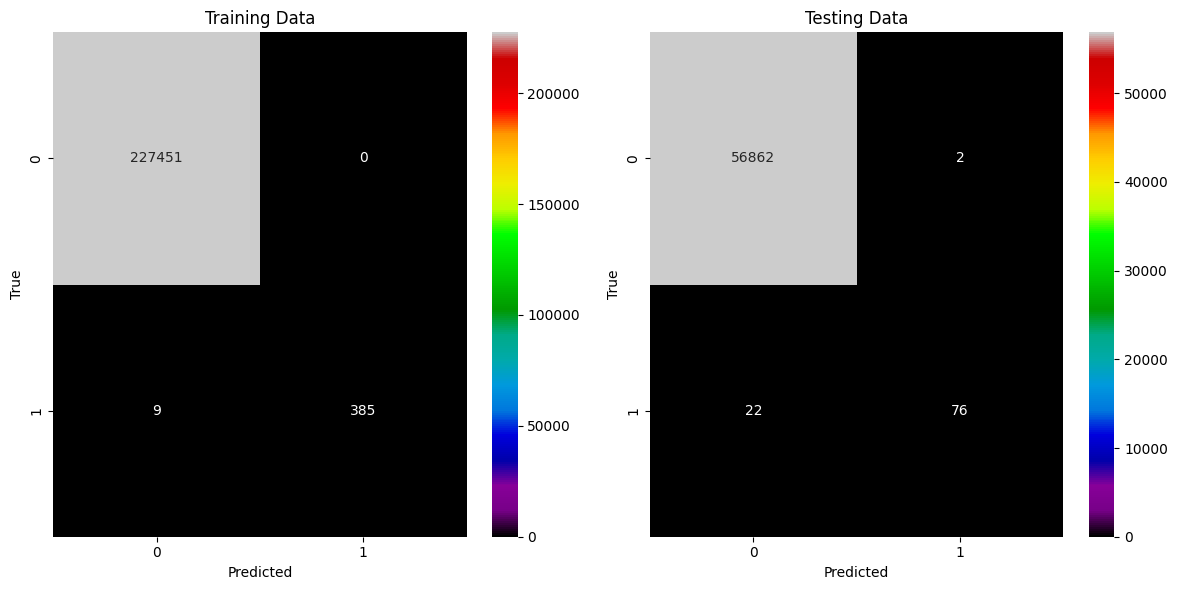

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:49:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=30, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99     

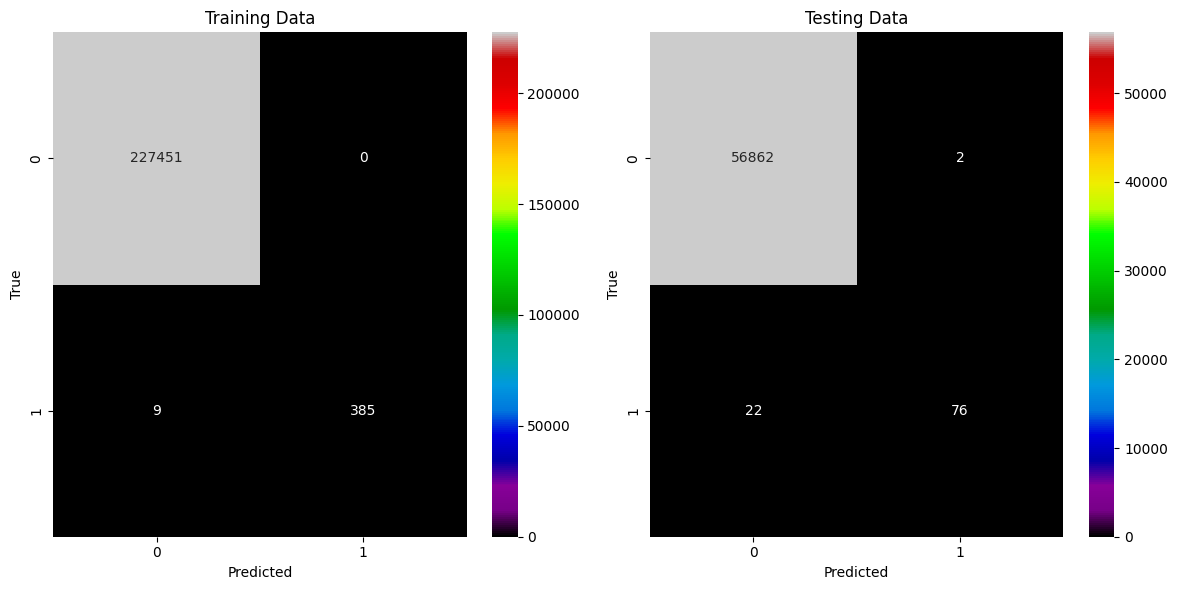

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

for m in models:
    m.fit(X_train, y_train)
    y_train_pred = m.predict(X_train)
    y_test_pred = m.predict(X_test)

    print(m)
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0], cmap='nipy_spectral')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1], cmap='nipy_spectral')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end

# Calculating AUPRC Score

In [ ]:
from sklearn.metrics import roc_curve, auc


model_to_evaluate = models[8] # Change this to select a different model

y_score = model_to_evaluate.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

print('ROC AUC score for the XGBClassifier max leaf node of 30 is' ,roc_auc)

ROC AUC score for the XGBClassifier max leaf node of 30 is 0.9412377042826134


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

model_to_evaluate = models[8] #  Change this to select a different model

y_score = model_to_evaluate.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
auprc = auc(recall, precision)

print('AUPRC score for the XGBClassifier max leaf node of 30 is' ,auprc)

AUPRC score for the XGBClassifier max leaf node of 30 is 0.8288084842582071


#AUROC optimizes for False Positive Rate, AUROC will always be high around (0.98) because customer servicee is filteering false alarm

# AUPRC prioritze precison, if model throws 200 false alarm precision falters affecting AUPRC score forcing the model to be precise about rare class (fraud).

*   AUROC false positive rate
*   AUPRC isolate precision (ignore true negatives)



In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

model_to_evaluate = models[8] # Change this to select a different model

y_score = model_to_evaluate.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_score)
auroc = roc_auc_score(y_test, y_score)
print("AUPRC:", auprc)
print("AUROC:", auroc)

AUPRC: 0.8288984639174196
AUROC: 0.9412377042826134


===========================================================================

#PyG: Graphical Convolution Network for fraud detection

===========================================================================

In [1]:
! pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

In [5]:
data = pd.read_csv('/content/drive/MyDrive/Final_Transactions.csv')
data.head()

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,0,2023-01-01 00:00:31,596,3156,533.07,31,0,0,0
1,1,1,2023-01-01 00:02:10,4961,3412,808.56,130,0,0,0
2,2,2,2023-01-01 00:07:56,2,1365,1442.94,476,0,1,1
3,3,3,2023-01-01 00:09:29,4128,8737,620.65,569,0,0,0
4,4,4,2023-01-01 00:10:34,927,9906,490.66,634,0,0,0


In [6]:
df = data.drop('Unnamed: 0', axis=1)
df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2023-01-01 00:00:31,596,3156,533.07,31,0,0,0
1,1,2023-01-01 00:02:10,4961,3412,808.56,130,0,0,0
2,2,2023-01-01 00:07:56,2,1365,1442.94,476,0,1,1
3,3,2023-01-01 00:09:29,4128,8737,620.65,569,0,0,0
4,4,2023-01-01 00:10:34,927,9906,490.66,634,0,0,0


#Scaling using Standard Scaler

In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#minmax_scaler = MinMaxScaler()
std_scaler = StandardScaler()

# Select numerical feature columns for scaling
# Exclude 'TX_DATETIME' (non-numeric) and 'TX_FRAUD' (target variable)
feature_columns = df.drop(columns=['TX_DATETIME', 'TX_FRAUD']).columns

# Apply StandardScaler to selected numerical feature columns
df_scaled = pd.DataFrame(std_scaler.fit_transform(df[feature_columns]), columns=feature_columns)
# end

# Principal Component Analysis

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=7)

df_scaled_pca = pd.DataFrame(
    pca.fit_transform(df_scaled)
)

In [13]:
feature_cols = [col for col in df_scaled_pca]
X_data = torch.tensor(df_scaled_pca[feature_cols].values, dtype=torch.float)
y_data = torch.tensor(df['TX_FRAUD'].values, dtype=torch.long)

# Building the topology

In [14]:
print('Lets build the graph structure :)')

Lets build the graph structure :)


# Train test Split

In [15]:
rows = np.arange(len(df)-1)
cols = rows + 1
edge_index = torch.tensor(np.vstack([np.append(rows, cols), np.append(cols, rows)]), dtype=torch.long)

#Package into PyG container
data = Data(x=X_data, edge_index = edge_index, y=y_data)

#Create a clean stratified train/test split mask (80% training, 20% test)
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)
train_cutoff = int(0.8*num_nodes)

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[indices[:train_cutoff]] = 1 # or True
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[indices[train_cutoff:]] = 1 # or True


# Hyperparameter Tuning

In [16]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.3 MB/s eta 0:00:00


In [22]:
import optuna
import torch.nn as nn
from sklearn.metrics import roc_auc_score

def objective(trial):
    # 1. Define the search space for hyperparameters
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True) # Adjusted typical range for Adam weight decay

    # 2. Instantiate the FraudGCN model for this trial
    # Use X_data.shape[1] to get the correct number of input features
    current_model = FraudGCN(in_channels=X_data.shape[1]).to(device)
    optimizer = torch.optim.Adam(current_model.parameters(), lr=lr, weight_decay=weight_decay)

    # 3. PyTorch training loop for this trial
    current_model.train()
    for epoch in range(1, 51): # Using 50 epochs for tuning to speed up
        optimizer.zero_grad()
        out = current_model(data.x, data.edge_index)
        # Using nll_loss with class weights
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask], weight=class_weights)
        loss.backward()
        optimizer.step()

    # 4. Evaluate performance on the test set and return a metric to minimize
    current_model.eval()
    with torch.no_grad():
        logits = current_model(data.x, data.edge_index)
        probabilities = torch.exp(logits)[:, 1].cpu().numpy()
        test_mask_np = data.test_mask.cpu().numpy()
        y_true = data.y.cpu().numpy()[test_mask_np]
        y_prob = probabilities[test_mask_np]

        # Handle cases where y_true might contain only one class in the test set
        if len(np.unique(y_true)) < 2:
            return 1.0 # Return a bad score if AUROC cannot be computed

        auroc = roc_auc_score(y_true, y_prob)
        # Optuna minimizes by default, so return negative AUROC to maximize it
        return -auroc

# Create an Optuna study. 'minimize' direction for -AUROC means maximizing AUROC.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=7) # Run 7 trials

print("Best trial:")
trial = study.best_trial
print(f"  Value (AUROC): {-trial.value:.4f}") # Print the actual AUROC (positive value)
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-05-25 23:32:20,355] A new study created in memory with name: no-name-17b5530f-e685-4d44-8685-823a4c79e98c
[I 2026-05-25 23:34:30,127] Trial 0 finished with value: -0.9590836417400034 and parameters: {'learning_rate': 0.010505013760738896, 'weight_decay': 3.0514576246412857e-05}. Best is trial 0 with value: -0.9590836417400034.
[I 2026-05-25 23:36:35,170] Trial 1 finished with value: -0.47039066679194935 and parameters: {'learning_rate': 0.00017308444381826174, 'weight_decay': 4.535337714824878e-06}. Best is trial 0 with value: -0.9590836417400034.
[I 2026-05-25 23:38:47,187] Trial 2 finished with value: -0.43243810015872874 and parameters: {'learning_rate': 6.757577784983198e-05, 'weight_decay': 2.791938658885826e-06}. Best is trial 0 with value: -0.9590836417400034.
[I 2026-05-25 23:40:53,973] Trial 3 finished with value: -0.6033058934163982 and parameters: {'learning_rate': 0.00029351573055151316, 'weight_decay': 7.434942995612325e-05}. Best is trial 0 with value: -0.95908364

Best trial:
  Value (AUROC): 0.9591
  Params: 
    learning_rate: 0.010505013760738896
    weight_decay: 3.0514576246412857e-05


# Defining the GNN Architecture

In [25]:
class FraudGCN(torch.nn.Module):
    def __init__(self, in_channels):
        super(FraudGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, 16)
        self.conv2 = GCNConv(16, 2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize and push to GPU when turned on
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FraudGCN(in_channels=len(feature_cols)).to(device)
data = data.to(device)

# Calculate class weights
num_fraud = int(data.y[data.train_mask].sum())
num_non_fraud = int(data.train_mask.sum()) - num_fraud

# Inverse frequency scaling
fraud_weight = num_non_fraud / num_fraud if num_fraud > 0 else 1

class_weights = torch.tensor([1.0, fraud_weight], dtype=torch.float).to(device)

# Retrieve best hyperparameters from Optuna study
best_lr = study.best_trial.params['learning_rate']
best_weight_decay = study.best_trial.params['weight_decay']

optimizer = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=best_weight_decay)

# MODEL OPTIMIZATION LOOP

In [26]:
model.train()
for epoch in range(1, 101):
  optimizer.zero_grad()
  out = model(data.x, data.edge_index)

  # Run loss function only on training mask nodes using calculated weights
  loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask], weight=class_weights)
  loss.backward()
  optimizer.step()

  if epoch % 20 == 0:
    print(f"Epoch: {epoch:03d} |Structural Loss: {loss.item():.4f}")

Epoch: 020 |Structural Loss: 0.3881
Epoch: 040 |Structural Loss: 0.2726
Epoch: 060 |Structural Loss: 0.2532
Epoch: 080 |Structural Loss: 0.2469
Epoch: 100 |Structural Loss: 0.2434


#SciKit-Learn Evaluation Metrics

In [27]:
model.eval()
with torch.no_grad():
  logits = model(data.x, data.edge_index)

  #Turn log probabilities back to 0 and 1 Probability scales
  probabilities = torch.exp(logits)[:, 1].cpu().numpy()
  predictions = logits.argmax(dim=1).cpu().numpy()

  actuals = data.y.cpu().numpy()
  test_mask_np = data.test_mask.cpu().numpy()

# Isolate rows belongings to the unseen matrix
y_true = actuals[test_mask_np]
y_pred = predictions[test_mask_np]
y_prob = probabilities[test_mask_np]

# Calculate final metrics via scikit-learn
auroc = roc_auc_score(y_true, y_prob)
auprc = average_precision_score(y_true, y_prob)
conf_matrix = confusion_matrix(y_true, y_pred)

print("\n" + "="*40)
print("Final FRAUD GNN Performance")
print("="*40)
print(f"AUROC: {auroc:.4f}")
print(f"AUPRC: {auprc:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f" [True Negatives (non_fraud): {conf_matrix[0][0]:5d}]")
print(f" [False Negatives (fraud): {conf_matrix[1][0]:5d}]")
print("="*40)

print("\n Detailed Breakdown Class Report:")
print(classification_report(y_true, y_pred, target_names = ['non fraud', 'fraud']))




Final FRAUD GNN Performance
AUROC: 0.9590
AUPRC: 0.6995
Confusion Matrix:
[[275739  27764]
 [     2  47326]]
 [True Negatives (non_fraud): 275739]
 [False Negatives (fraud):     2]

 Detailed Breakdown Class Report:
              precision    recall  f1-score   support

   non fraud       1.00      0.91      0.95    303503
       fraud       0.63      1.00      0.77     47328

    accuracy                           0.92    350831
   macro avg       0.82      0.95      0.86    350831
weighted avg       0.95      0.92      0.93    350831



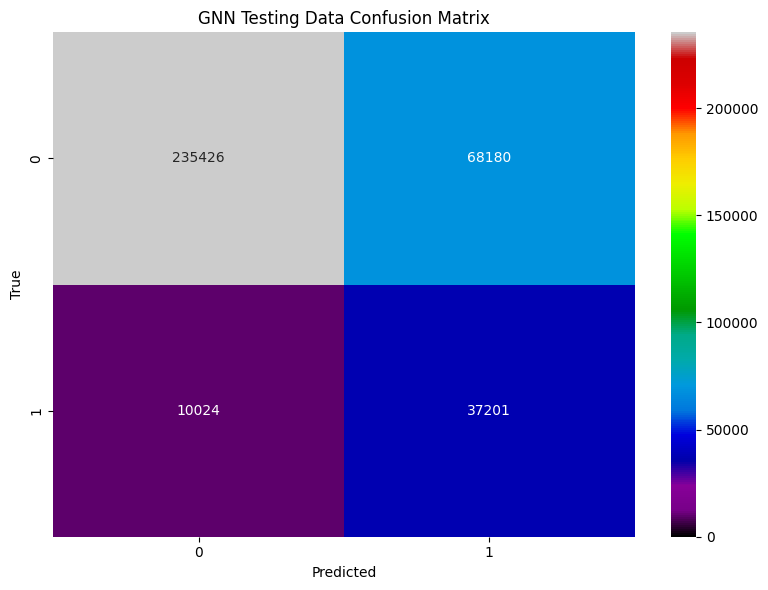


Detailed Breakdown Class Report (GNN):
              precision    recall  f1-score   support

   non fraud       0.96      0.78      0.86    303606
       fraud       0.35      0.79      0.49     47225

    accuracy                           0.78    350831
   macro avg       0.66      0.78      0.67    350831
weighted avg       0.88      0.78      0.81    350831



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Display Confusion Matrix for GNN
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, vmin=0, fmt='d', ax=ax, cmap='nipy_spectral')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("GNN Testing Data Confusion Matrix")
plt.tight_layout()
plt.show()

# Display Classification Report for GNN
print("\nDetailed Breakdown Class Report (GNN):")
print(classification_report(y_true, y_pred, target_names=['non fraud', 'fraud']))

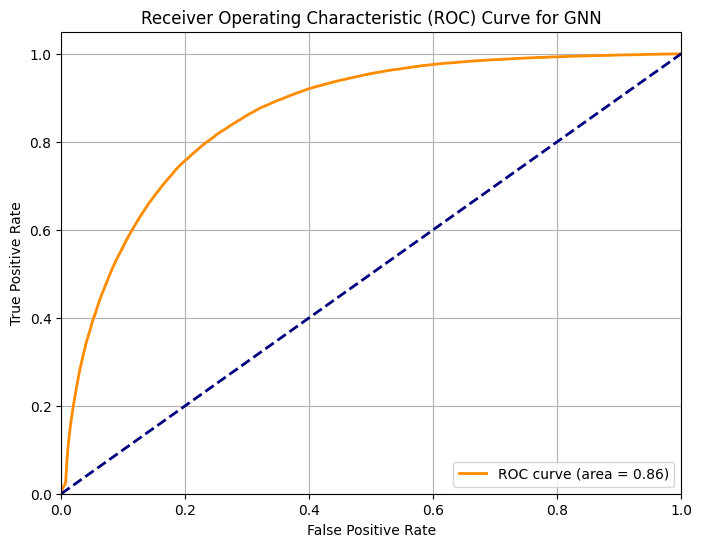

GNN AUPRC: 0.4623
GNN AUROC: 0.8600


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# Calculate AUPRC
auprc = average_precision_score(y_true, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for GNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"GNN AUPRC: {auprc:.4f}")
print(f"GNN AUROC: {roc_auc:.4f}")

Model achieved a Recall of ~0.79 (79% of fraud caught) with a Precision of ~0.35 (fraud caught is legitimate) at a threshold of 0.50.

prioritize a higher precision if the cost of a false positive is very high: For instance, if flagging a legitimate transaction causes severe customer dissatisfaction, lost business .. etc.

prioritize a higher recall if the cost of a fraudulent transaction leads to significant financial loss for the company, even if it comes with more false positives